# Deep Learning Regression with Optuna and MLflow

Dataset: `midterm-regresi-dataset.csv`.

This notebook treats column `0` as the regression target and columns `1..90` as numerical features. It covers data loading, preprocessing, feature engineering, PyTorch model training, Optuna tuning, MLflow tracking, final evaluation, and model comparison.


## 1. Setup

`QUICK_RUN` keeps the notebook practical on a laptop. For final submission, set `QUICK_RUN = False`, increase `N_TRIALS`, and rerun all cells.


In [1]:
from pathlib import Path
import sys
import warnings

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "midterm-regresi-dataset.csv"
MLFLOW_DB = PROJECT_ROOT / "mlflow.db"
MLFLOW_ARTIFACT_DIR = PROJECT_ROOT / "mlruns"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
MODEL_DIR = PROJECT_ROOT / "models"
MLFLOW_ARTIFACT_DIR.mkdir(exist_ok=True)
ARTIFACT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

QUICK_RUN = False
MAX_ROWS = 80_000 if QUICK_RUN else None
N_TRIALS = 5 if QUICK_RUN else 25
MAX_EPOCHS = 12 if QUICK_RUN else 50
PATIENCE = 4 if QUICK_RUN else 8
RANDOM_STATE = 42

assert DATA_PATH.exists(), f"Dataset not found: {DATA_PATH}"
print("Project root:", PROJECT_ROOT)


Project root: D:\ML-Final Term


In [2]:
import joblib
import mlflow
import mlflow.pytorch
import numpy as np
import optuna
import pandas as pd
import torch
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from src.tabular_dl import (
    MLP,
    ResidualMLP,
    add_numeric_summary_features,
    get_device,
    make_loader,
    predict_torch_model,
    seed_everything,
    to_numpy_dense,
    train_torch_model,
)

seed_everything(RANDOM_STATE)
device = get_device()
MLFLOW_EXPERIMENT = "uas_regression_deep_learning"
mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB.as_posix()}")
if mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT) is None:
    mlflow.create_experiment(MLFLOW_EXPERIMENT, artifact_location=MLFLOW_ARTIFACT_DIR.as_uri())
mlflow.set_experiment(MLFLOW_EXPERIMENT)

def mlflow_safe_params(params):
    return {k: str(v) if isinstance(v, (list, tuple, dict)) else v for k, v in params.items()}

print("Device:", device)
print("MLflow tracking URI:", mlflow.get_tracking_uri())


Device: cpu
MLflow tracking URI: sqlite:///D:/ML-Final Term/mlflow.db


## 2. Load Data

The CSV has no header. The first column becomes `target_year`; every remaining column becomes a named numerical feature.


In [3]:
df = pd.read_csv(DATA_PATH, header=None, nrows=MAX_ROWS)
feature_names = [f"feature_{i:03d}" for i in range(1, df.shape[1])]
df.columns = ["target_year"] + feature_names

display(df.head())
print("Shape:", df.shape)
print(df["target_year"].describe())


,target_year,feature_001,feature_002,feature_003,feature_004,feature_005,feature_006,feature_007,feature_008,feature_009,...,feature_081,feature_082,feature_083,feature_084,feature_085,feature_086,feature_087,feature_088,feature_089,feature_090
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


Shape: (515345, 91)
count    515345.000000
mean       1998.397082
std          10.931046
min        1922.000000
25%        1994.000000
50%        2002.000000
75%        2006.000000
max        2011.000000
Name: target_year, dtype: float64


## 3. Feature Engineering and Split

Row-level numeric summary features are added before imputation/scaling. The data is split into train, validation, and test sets so Optuna only sees validation feedback.


In [4]:
X_raw = add_numeric_summary_features(df.drop(columns=["target_year"]))
y = df["target_year"].astype("float32")

X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X_raw, y, test_size=0.30, random_state=RANDOM_STATE
)
X_valid_raw, X_test_raw, y_valid, y_test = train_test_split(
    X_temp_raw, y_temp, test_size=0.50, random_state=RANDOM_STATE
)

x_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
y_scaler = StandardScaler()

X_train = to_numpy_dense(x_pipeline.fit_transform(X_train_raw))
X_valid = to_numpy_dense(x_pipeline.transform(X_valid_raw))
X_test = to_numpy_dense(x_pipeline.transform(X_test_raw))

y_train_scaled = y_scaler.fit_transform(y_train.to_numpy().reshape(-1, 1)).reshape(-1).astype("float32")
y_valid_scaled = y_scaler.transform(y_valid.to_numpy().reshape(-1, 1)).reshape(-1).astype("float32")
y_test_scaled = y_scaler.transform(y_test.to_numpy().reshape(-1, 1)).reshape(-1).astype("float32")

joblib.dump(x_pipeline, MODEL_DIR / "regression_x_pipeline.joblib")
joblib.dump(y_scaler, MODEL_DIR / "regression_y_scaler.joblib")

print("Train:", X_train.shape, "Valid:", X_valid.shape, "Test:", X_test.shape)


Train: (360741, 95) Valid: (77302, 95) Test: (77302, 95)


## 4. Model and Evaluation Helpers

The model is trained on a standardized target, then predictions are converted back to the original target scale for MAE, RMSE, and R2.


In [5]:
def build_model(params, input_dim):
    model_type = params.get("model_type", "mlp")
    dropout = float(params.get("dropout", 0.1))
    batch_norm = bool(params.get("batch_norm", True))
    if model_type == "residual_mlp":
        return ResidualMLP(
            input_dim=input_dim,
            width=int(params.get("width", 128)),
            n_blocks=int(params.get("n_blocks", 3)),
            dropout=dropout,
            batch_norm=batch_norm,
        )
    return MLP(
        input_dim=input_dim,
        hidden_dims=params.get("hidden_dims", [128, 64]),
        dropout=dropout,
        batch_norm=batch_norm,
    )

def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": float(np.sqrt(mse)),
        "r2": r2_score(y_true, y_pred),
    }

def evaluate_model(model, batch_size=1024):
    test_loader = make_loader(X_test, y_test_scaled, batch_size=batch_size, shuffle=False)
    pred_scaled = predict_torch_model(model, test_loader, device=device)
    pred = y_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).reshape(-1)
    return regression_metrics(y_test.to_numpy(), pred), pred


## 5. Train Fixed Architectures

These fixed MLP runs provide comparison points before hyperparameter tuning.


In [6]:
fixed_architectures = {
    "baseline_mlp": {
        "model_type": "mlp",
        "hidden_dims": [128, 64],
        "dropout": 0.10,
        "batch_norm": True,
        "lr": 1e-3,
        "weight_decay": 1e-5,
        "batch_size": 512,
    },
    "deep_mlp": {
        "model_type": "mlp",
        "hidden_dims": [256, 128, 64],
        "dropout": 0.20,
        "batch_norm": True,
        "lr": 8e-4,
        "weight_decay": 1e-5,
        "batch_size": 512,
    },
}

results = []

for run_name, params in fixed_architectures.items():
    seed_everything(RANDOM_STATE)
    batch_size = int(params["batch_size"])
    train_loader = make_loader(X_train, y_train_scaled, batch_size=batch_size, shuffle=True)
    valid_loader = make_loader(X_valid, y_valid_scaled, batch_size=batch_size, shuffle=False)
    model = build_model(params, input_dim=X_train.shape[1])

    with mlflow.start_run(run_name=f"regression_{run_name}"):
        mlflow.log_params(mlflow_safe_params(params))
        mlflow.log_param("max_rows", MAX_ROWS)
        train_result = train_torch_model(
            model,
            train_loader,
            valid_loader,
            task="regression",
            lr=float(params["lr"]),
            weight_decay=float(params["weight_decay"]),
            epochs=MAX_EPOCHS,
            patience=PATIENCE,
            device=device,
        )
        for row in train_result.history:
            mlflow.log_metric("train_loss", row["train_loss"], step=int(row["epoch"]))
            mlflow.log_metric("valid_loss", row["valid_loss"], step=int(row["epoch"]))
        metrics, _ = evaluate_model(model, batch_size=batch_size)
        mlflow.log_metrics(metrics)
        mlflow.log_metric("best_valid_loss", train_result.best_valid_loss)
        mlflow.pytorch.log_model(model, artifact_path="model", serialization_format="pickle")

    results.append({"model": run_name, **metrics, "best_valid_loss": train_result.best_valid_loss})
    print(run_name, metrics)

pd.DataFrame(results)


2026/06/24 18:06:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/24 18:06:56 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


baseline_mlp {'mae': 5.901421070098877, 'rmse': 8.608885375567965, 'r2': 0.3849831819534302}


2026/06/24 18:12:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/24 18:12:19 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


deep_mlp {'mae': 5.791510105133057, 'rmse': 8.51621315701084, 'r2': 0.3981528878211975}


,model,mae,rmse,r2,best_valid_loss
0,baseline_mlp,5.901421,8.608885,0.384983,0.610240
1,deep_mlp,5.791510,8.516213,0.398153,0.599258


## 6. Optuna Hyperparameter Tuning

Optuna searches across MLP and Residual MLP variants. Every trial is logged as a nested MLflow run.


In [7]:
def suggest_params(trial):
    model_type = trial.suggest_categorical("model_type", ["mlp", "residual_mlp"])
    params = {
        "model_type": model_type,
        "dropout": trial.suggest_float("dropout", 0.0, 0.4),
        "batch_norm": trial.suggest_categorical("batch_norm", [True, False]),
        "lr": trial.suggest_float("lr", 1e-4, 3e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-7, 1e-3, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [256, 512, 1024]),
    }
    if model_type == "residual_mlp":
        params["width"] = trial.suggest_categorical("width", [64, 128, 256])
        params["n_blocks"] = trial.suggest_int("n_blocks", 2, 5)
    else:
        n_layers = trial.suggest_int("n_layers", 2, 4)
        first_width = trial.suggest_categorical("first_width", [64, 128, 256])
        params["hidden_dims"] = [max(first_width // (2 ** i), 32) for i in range(n_layers)]
    return params

def objective(trial):
    seed_everything(RANDOM_STATE + trial.number)
    params = suggest_params(trial)
    batch_size = int(params["batch_size"])
    train_loader = make_loader(X_train, y_train_scaled, batch_size=batch_size, shuffle=True)
    valid_loader = make_loader(X_valid, y_valid_scaled, batch_size=batch_size, shuffle=False)
    model = build_model(params, input_dim=X_train.shape[1])

    with mlflow.start_run(run_name=f"regression_trial_{trial.number}", nested=True):
        mlflow.log_params(mlflow_safe_params(params))
        train_result = train_torch_model(
            model,
            train_loader,
            valid_loader,
            task="regression",
            lr=float(params["lr"]),
            weight_decay=float(params["weight_decay"]),
            epochs=MAX_EPOCHS,
            patience=PATIENCE,
            device=device,
        )
        mlflow.log_metric("best_valid_loss", train_result.best_valid_loss)
        mlflow.log_metric("best_epoch", train_result.best_epoch)
    return train_result.best_valid_loss

with mlflow.start_run(run_name="regression_optuna_study"):
    study = optuna.create_study(direction="minimize", study_name="regression_pytorch_tuning")
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    mlflow.log_params({f"best_{k}": v for k, v in mlflow_safe_params(study.best_params).items()})
    mlflow.log_metric("best_value", study.best_value)

print("Best value:", study.best_value)
print("Best params:", study.best_params)


[I 2026-06-24 18:12:25,152] A new study created in memory with name: regression_pytorch_tuning


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-06-24 18:16:31,000] Trial 0 finished with value: 0.6120122123565258 and parameters: {'model_type': 'residual_mlp', 'dropout': 0.37085820348182463, 'batch_norm': False, 'lr': 0.0009069441913100731, 'weight_decay': 1.119719361614576e-05, 'batch_size': 256, 'width': 128, 'n_blocks': 4}. Best is trial 0 with value: 0.6120122123565258.
[I 2026-06-24 18:20:57,589] Trial 1 finished with value: 0.6026222143443768 and parameters: {'model_type': 'mlp', 'dropout': 0.22713610248419025, 'batch_norm': False, 'lr': 0.0014684228593984164, 'weight_decay': 2.314752942553795e-06, 'batch_size': 1024, 'n_layers': 3, 'first_width': 256}. Best is trial 1 with value: 0.6026222143443768.
[I 2026-06-24 18:25:52,993] Trial 2 finished with value: 0.6236888594357324 and parameters: {'model_type': 'mlp', 'dropout': 0.2974529869927495, 'batch_norm': False, 'lr': 0.00041049949001190365, 'weight_decay': 2.0913151361185364e-06, 'batch_size': 1024, 'n_layers': 3, 'first_width': 64}. Best is trial 1 with value: 0

## 7. Train Final Tuned Model

The best Optuna parameters are retrained and evaluated on the reserved test set.


In [8]:
best_params = suggest_params(optuna.trial.FixedTrial(study.best_params))
seed_everything(RANDOM_STATE)
batch_size = int(best_params["batch_size"])
train_loader = make_loader(X_train, y_train_scaled, batch_size=batch_size, shuffle=True)
valid_loader = make_loader(X_valid, y_valid_scaled, batch_size=batch_size, shuffle=False)
best_model = build_model(best_params, input_dim=X_train.shape[1])

with mlflow.start_run(run_name="regression_optuna_best_model"):
    mlflow.log_params(mlflow_safe_params(best_params))
    train_result = train_torch_model(
        best_model,
        train_loader,
        valid_loader,
        task="regression",
        lr=float(best_params["lr"]),
        weight_decay=float(best_params["weight_decay"]),
        epochs=MAX_EPOCHS,
        patience=PATIENCE,
        device=device,
    )
    for row in train_result.history:
        mlflow.log_metric("train_loss", row["train_loss"], step=int(row["epoch"]))
        mlflow.log_metric("valid_loss", row["valid_loss"], step=int(row["epoch"]))
    metrics, predictions = evaluate_model(best_model, batch_size=batch_size)
    mlflow.log_metrics(metrics)
    mlflow.log_metric("best_valid_loss", train_result.best_valid_loss)
    mlflow.pytorch.log_model(best_model, artifact_path="model", serialization_format="pickle")

torch.save(best_model.state_dict(), MODEL_DIR / "regression_optuna_best_model.pt")
results.append({"model": "optuna_best", **metrics, "best_valid_loss": train_result.best_valid_loss})

results_df = pd.DataFrame(results).sort_values("rmse")
display(results_df)
results_df.to_csv(ARTIFACT_DIR / "regression_results.csv", index=False)


2026/06/24 20:34:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/24 20:34:08 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


,model,mae,rmse,r2,best_valid_loss
1,deep_mlp,5.791510,8.516213,0.398153,0.599258
2,optuna_best,5.788441,8.536731,0.395249,0.602261
0,baseline_mlp,5.901421,8.608885,0.384983,0.610240


## 8. Error Analysis

The scatter plot checks whether predictions follow the target scale or collapse toward the mean.


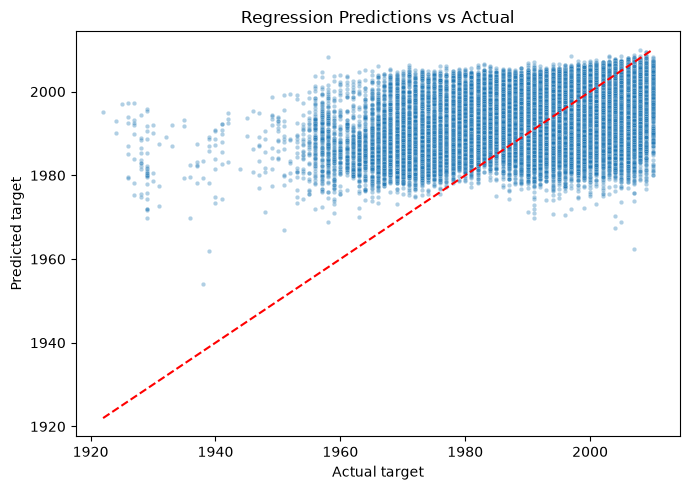

Saved plot to D:\ML-Final Term\artifacts\regression_predictions_vs_actual.png


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test.to_numpy(), y=predictions, s=10, alpha=0.35)
min_value = min(float(np.min(y_test)), float(np.min(predictions)))
max_value = max(float(np.max(y_test)), float(np.max(predictions)))
plt.plot([min_value, max_value], [min_value, max_value], color="red", linestyle="--")
plt.xlabel("Actual target")
plt.ylabel("Predicted target")
plt.title("Regression Predictions vs Actual")
plt.tight_layout()
plot_path = ARTIFACT_DIR / "regression_predictions_vs_actual.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print("Saved plot to", plot_path)


## 9. Conclusion Notes

Use the results table and MLflow runs to write the final analysis. Discuss which architecture had the lowest RMSE/MAE and whether Optuna improved over fixed hyperparameters.
